**Project: Loan Approval Prediction**

**Dataset:** Loan Approval Classification Data (Kaggle, ~45,000 loan applications)  
**Target Variable:** `loan_status` (0 = Rejected / Not Approved, 1 = Approved)  
**Task Type:** Binary Classification  
**Business Problem:** Classifying loan applications as **Approved** or **Rejected**  
**Models:** Logistic Regression · Decision Tree · Random Forest · K-Nearest Neighbours · Gradient Boosting · Gaussian Naive Bayes · AdaBoost · Extra Trees

---

## Table of Contents
1. [Environment Setup & Data Loading](#1)
2. [Data Overview & Quality Check](#2)
3. [Data Preprocessing](#3)
4. [Exploratory Data Analysis (EDA)](#4)
5. [Feature Selection](#5)
6. [Model Building](#6)
7. [Model Optimization](#7)
8. [Model Evaluation](#8)
9. [Business Insights & Recommendations](#9)
10. [GitHub Submission Checklist](#10)


## 1. Environment Setup & Data Loading <a id='1'></a>


In [ ]:
# The dataset is downloaded from Kaggle using kagglehub.

!pip -q install kagglehub


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Sklearn - preprocessing, selection, splitting and tuning
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.utils.class_weight import compute_class_weight

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

import kagglehub

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

APPROVAL_COLORS = {0: '#C44E52', 1: '#55A868'}
MODEL_COLORS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860', '#DA8BC3', '#8C8C8C']

RANDOM_STATE = 42


In [ ]:
# Download dataset from Kaggle
# Dataset page: https://www.kaggle.com/datasets/taweilo/loan-approval-classification-data

path = kagglehub.dataset_download('taweilo/loan-approval-classification-data')
print('Dataset downloaded to:', path)

csv_files = glob.glob(os.path.join(path, '*.csv'))
print('CSV files found:', csv_files)

# The dataset contains loan_data.csv
csv_path = [f for f in csv_files if 'loan_data' in os.path.basename(f).lower()][0]

df_raw = pd.read_csv(csv_path)
df = df_raw.copy()

print(f"Dataset shape : {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()


Using Colab cache for faster access to the 'loan-approval-classification-data' dataset.
Dataset downloaded to: /kaggle/input/loan-approval-classification-data
CSV files found: ['/kaggle/input/loan-approval-classification-data/loan_data.csv']
Dataset shape : 45,000 rows x 14 columns


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


## 2. Data Overview & Quality Check <a id='2'></a>


In [ ]:
info = pd.DataFrame({
    'dtype'      : df.dtypes,
    'non_null'   : df.notna().sum(),
    'null_count' : df.isna().sum(),
    'null_%'     : (df.isna().mean() * 100).round(2),
    'unique'     : df.nunique(),
    'sample_val' : df.iloc[0],
})
info


,dtype,non_null,null_count,null_%,unique,sample_val
person_age,float64,45000,0,0.0,60,22.0
person_gender,object,45000,0,0.0,2,female
person_education,object,45000,0,0.0,5,Master
person_income,float64,45000,0,0.0,33989,71948.0
person_emp_exp,int64,45000,0,0.0,63,0
person_home_ownership,object,45000,0,0.0,4,RENT
loan_amnt,float64,45000,0,0.0,4483,35000.0
loan_intent,object,45000,0,0.0,6,PERSONAL
loan_int_rate,float64,45000,0,0.0,1302,16.02
loan_percent_income,float64,45000,0,0.0,64,0.49


In [ ]:
df.describe(include='all')


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
count,45000.000000,45000,45000,4.500000e+04,45000.000000,45000,45000.000000,45000,45000.000000,45000.000000,45000.000000,45000.000000,45000,45000.000000
unique,NaN,2,5,NaN,NaN,4,NaN,6,NaN,NaN,NaN,NaN,2,NaN
top,NaN,male,Bachelor,NaN,NaN,RENT,NaN,EDUCATION,NaN,NaN,NaN,NaN,Yes,NaN
freq,NaN,24841,13399,NaN,NaN,23443,NaN,9153,NaN,NaN,NaN,NaN,22858,NaN
mean,27.764178,NaN,NaN,8.031905e+04,5.410333,NaN,9583.157556,NaN,11.006606,0.139725,5.867489,632.608756,NaN,0.222222
std,6.045108,NaN,NaN,8.042250e+04,6.063532,NaN,6314.886691,NaN,2.978808,0.087212,3.879702,50.435865,NaN,0.415744
min,20.000000,NaN,NaN,8.000000e+03,0.000000,NaN,500.000000,NaN,5.420000,0.000000,2.000000,390.000000,NaN,0.000000
25%,24.000000,NaN,NaN,4.720400e+04,1.000000,NaN,5000.000000,NaN,8.590000,0.070000,3.000000,601.000000,NaN,0.000000
50%,26.000000,NaN,NaN,6.704800e+04,4.000000,NaN,8000.000000,NaN,11.010000,0.120000,4.000000,640.000000,NaN,0.000000
75%,30.000000,NaN,NaN,9.578925e+04,8.000000,NaN,12237.250000,NaN,12.990000,0.190000,8.000000,670.000000,NaN,0.000000


In [ ]:
df.shape


(45000, 14)

In [ ]:
# Target variable check
print(df['loan_status'].value_counts())
print('\nTarget distribution (%):')
print((df['loan_status'].value_counts(normalize=True) * 100).round(2))


loan_status
0    35000
1    10000
Name: count, dtype: int64

Target distribution (%):
loan_status
0    77.78
1    22.22
Name: proportion, dtype: float64


## 3. Data Preprocessing <a id='3'></a>


### 3.1 Standardize Column Names and Target Labels


In [ ]:
# Clean column names so they are easier to use in Python
original_columns = df.columns.tolist()
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(' ', '_')
      .str.replace('-', '_')
)

print('Original columns:', original_columns)
print('Cleaned columns :', df.columns.tolist())

# Convert target to binary format: 1 = Approved, 0 = Rejected / Not Approved
if df['loan_status'].dtype == 'object':
    df['loan_status'] = df['loan_status'].str.strip().str.lower()
    df['loan_status'] = df['loan_status'].map({
        'approved': 1,
        'approve': 1,
        'yes': 1,
        'y': 1,
        '1': 1,
        'not approved': 0,
        'rejected': 0,
        'reject': 0,
        'no': 0,
        'n': 0,
        '0': 0
    })

# If Kaggle already stores loan_status as 0/1, this keeps it numeric
if df['loan_status'].isna().sum() > 0:
    print('Warning: target has unmapped values. Unique values are:')
    print(df_raw['loan_status'].unique())

df['loan_status'] = df['loan_status'].astype(int)
print(df['loan_status'].value_counts())


Original columns: ['person_age', 'person_gender', 'person_education', 'person_income', 'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'previous_loan_defaults_on_file', 'loan_status']
Cleaned columns : ['person_age', 'person_gender', 'person_education', 'person_income', 'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'previous_loan_defaults_on_file', 'loan_status']
loan_status
0    35000
1    10000
Name: count, dtype: int64


### 3.2 Duplicates


In [ ]:
dupes = df.duplicated().sum()
print(f"Duplicate rows found: {dupes}")
df.drop_duplicates(inplace=True)
print(f"Shape after dedup   : {df.shape}")


Duplicate rows found: 0
Shape after dedup   : (45000, 14)


### 3.3 Missing Values


In [ ]:
missing = df.isnull().sum()
missing = missing[missing > 0]

if missing.empty:
    print('No missing values detected.')
else:
    print('Missing values before imputation:')
    print(missing)
    num_cols = df.select_dtypes(include='number').columns.drop('loan_status', errors='ignore')
    cat_cols = df.select_dtypes(include='object').columns
    df[num_cols] = df[num_cols].fillna(df[num_cols].median())
    for c in cat_cols:
        df[c] = df[c].fillna(df[c].mode()[0])
    print('\nMissing values after imputation:', df.isna().sum().sum())


No missing values detected.


### 3.4 Outlier Detection & Capping (IQR Winsorisation)


Continuous features used for outlier treatment:
['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']


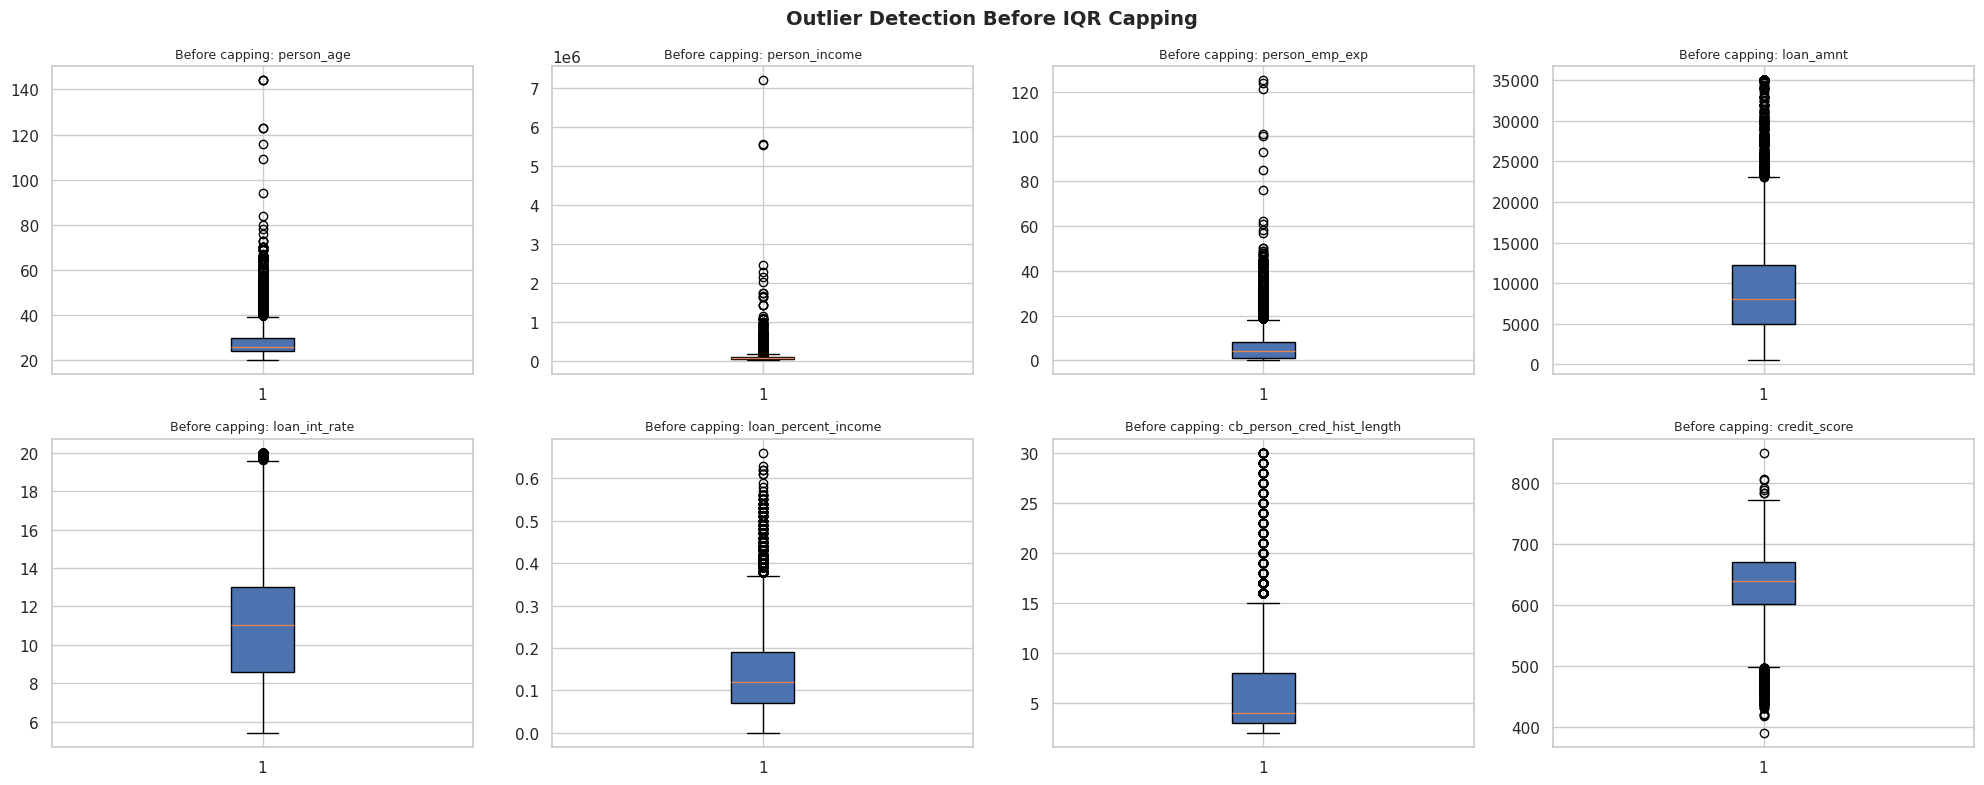

,feature,outliers,lower_fence,upper_fence
3,loan_amnt,2348,-5855.88,23093.12
1,person_income,2218,-25673.88,168667.12
0,person_age,2188,15.00,39.00
2,person_emp_exp,1724,-9.50,18.50
6,cb_person_cred_hist_length,1366,-4.50,15.50
5,loan_percent_income,744,-0.11,0.37
7,credit_score,467,497.50,773.50
4,loan_int_rate,124,1.99,19.59


In [ ]:
# Select continuous numeric features except the target
numeric_cols = df.select_dtypes(include='number').columns.tolist()
continuous_feats = [c for c in numeric_cols if c != 'loan_status' and df[c].nunique() > 10]

# The dataset may include unrealistic ages over 100, so age is capped by the same IQR rule.
print('Continuous features used for outlier treatment:')
print(continuous_feats)

n = len(continuous_feats)
cols = min(4, n)
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = np.array(axes).reshape(-1)
outlier_summary = []

for i, col in enumerate(continuous_feats):
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    outlier_summary.append({'feature': col, 'outliers': n_out,
                             'lower_fence': round(lo, 2), 'upper_fence': round(hi, 2)})

    axes[i].boxplot(df[col], vert=True, patch_artist=True)
    axes[i].set_title(f'Before capping: {col}', fontsize=9)
    df[col] = df[col].clip(lo, hi)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Outlier Detection Before IQR Capping', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('01_outlier_detection.png', bbox_inches='tight')
plt.show()

pd.DataFrame(outlier_summary).sort_values('outliers', ascending=False)


### 3.5 Feature Engineering


In [ ]:
# Create business-friendly financial ratios where columns are available.
created_features = []

if {'loan_amnt', 'person_income'}.issubset(df.columns):
    df['loan_to_income_ratio'] = (df['loan_amnt'] / (df['person_income'] + 1)).round(4)
    created_features.append('loan_to_income_ratio')

if {'loan_percent_income'}.issubset(df.columns):
    df['high_loan_burden'] = (df['loan_percent_income'] >= df['loan_percent_income'].quantile(0.75)).astype(int)
    created_features.append('high_loan_burden')

if {'person_age', 'person_emp_length'}.issubset(df.columns):
    df['employment_to_age_ratio'] = (df['person_emp_length'] / (df['person_age'] + 1)).round(4)
    created_features.append('employment_to_age_ratio')

if {'credit_score'}.issubset(df.columns):
    df['high_credit_score'] = (df['credit_score'] >= df['credit_score'].median()).astype(int)
    created_features.append('high_credit_score')

print('New features created:', created_features if created_features else 'No additional features created')
df[created_features].describe() if created_features else df.head()


New features created: ['loan_to_income_ratio', 'high_loan_burden', 'high_credit_score']


,loan_to_income_ratio,high_loan_burden,high_credit_score
count,45000.000000,45000.000000,45000.000000
mean,0.139349,0.259222,0.500578
std,0.084650,0.438213,0.500005
min,0.005900,0.000000,0.000000
25%,0.075100,0.000000,0.000000
50%,0.123300,0.000000,1.000000
75%,0.186000,1.000000,1.000000
max,0.664200,1.000000,1.000000


### 3.6 Encoding & Scaling Preparation


In [ ]:
# Drop obvious ID columns if they exist
id_like_cols = [c for c in df.columns if c.endswith('_id') or c == 'id']
df_ml = df.drop(columns=id_like_cols, errors='ignore')

cat_cols = df_ml.select_dtypes(include='object').columns.tolist()
print(f"Categorical cols to encode: {cat_cols}")

df_encoded = pd.get_dummies(df_ml, columns=cat_cols, drop_first=True)
df_encoded.columns = df_encoded.columns.str.replace('[^A-Za-z0-9_]', '_', regex=True)

print(f"Shape after encoding: {df_encoded.shape}")
df_encoded.head(3)


Categorical cols to encode: ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']
Shape after encoding: (45000, 26)


,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status,loan_to_income_ratio,...,person_education_Master,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,previous_loan_defaults_on_file_Yes
0,22.0,71948.0,0.0,23093.125,16.02,0.37,3.0,561.0,1,0.3210,...,True,False,False,True,False,False,False,True,False,False
1,21.0,12282.0,0.0,1000.000,11.14,0.08,2.0,504.0,0,0.0814,...,False,False,True,False,True,False,False,False,False,True
2,25.0,12438.0,3.0,5500.000,12.87,0.37,3.0,635.0,1,0.4422,...,False,False,False,False,False,False,True,False,False,False


## 4. Exploratory Data Analysis (EDA) <a id='4'></a>


### 4.1 Target Distribution


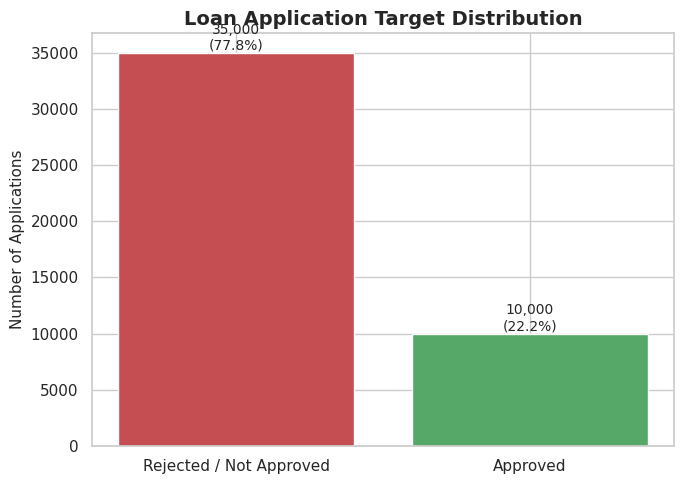

In [ ]:
target_counts = df['loan_status'].value_counts().sort_index()
labels = ['Rejected / Not Approved', 'Approved']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, target_counts.values, color=[APPROVAL_COLORS[0], APPROVAL_COLORS[1]], edgecolor='white')
ax.set_title('Loan Application Target Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Applications')

for bar, count in zip(bars, target_counts.values):
    pct = count / target_counts.sum() * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{count:,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('02_target_distribution.png', bbox_inches='tight')
plt.show()


### 4.2 Numeric Feature Distributions by Loan Status


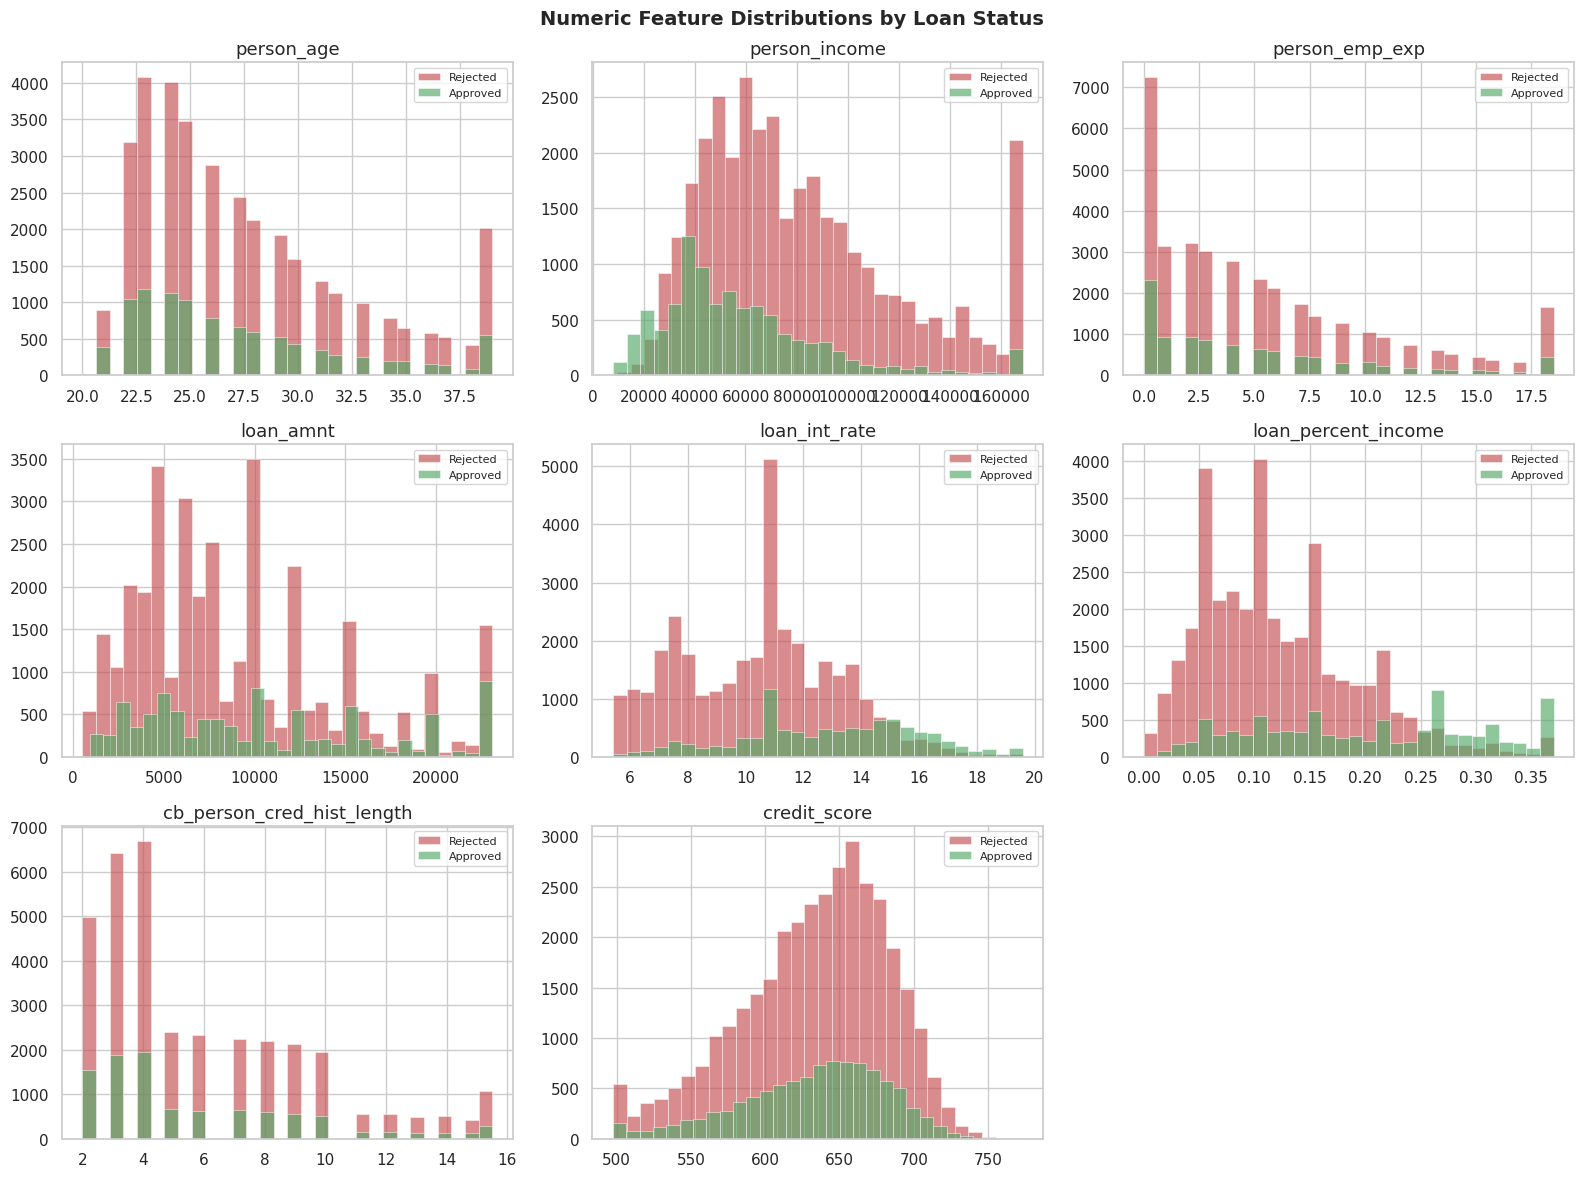

In [ ]:
plot_numeric = continuous_feats[:9]
cols = 3
rows = int(np.ceil(len(plot_numeric) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(plot_numeric):
    for label, grp in df.groupby('loan_status')[col]:
        axes[i].hist(grp, bins=30, alpha=0.65,
                     label='Approved' if label == 1 else 'Rejected',
                     color=APPROVAL_COLORS[label], edgecolor='white', linewidth=0.5)
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numeric Feature Distributions by Loan Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('03_numeric_distributions.png', bbox_inches='tight')
plt.show()


### 4.3 Categorical Features vs Approval Rate


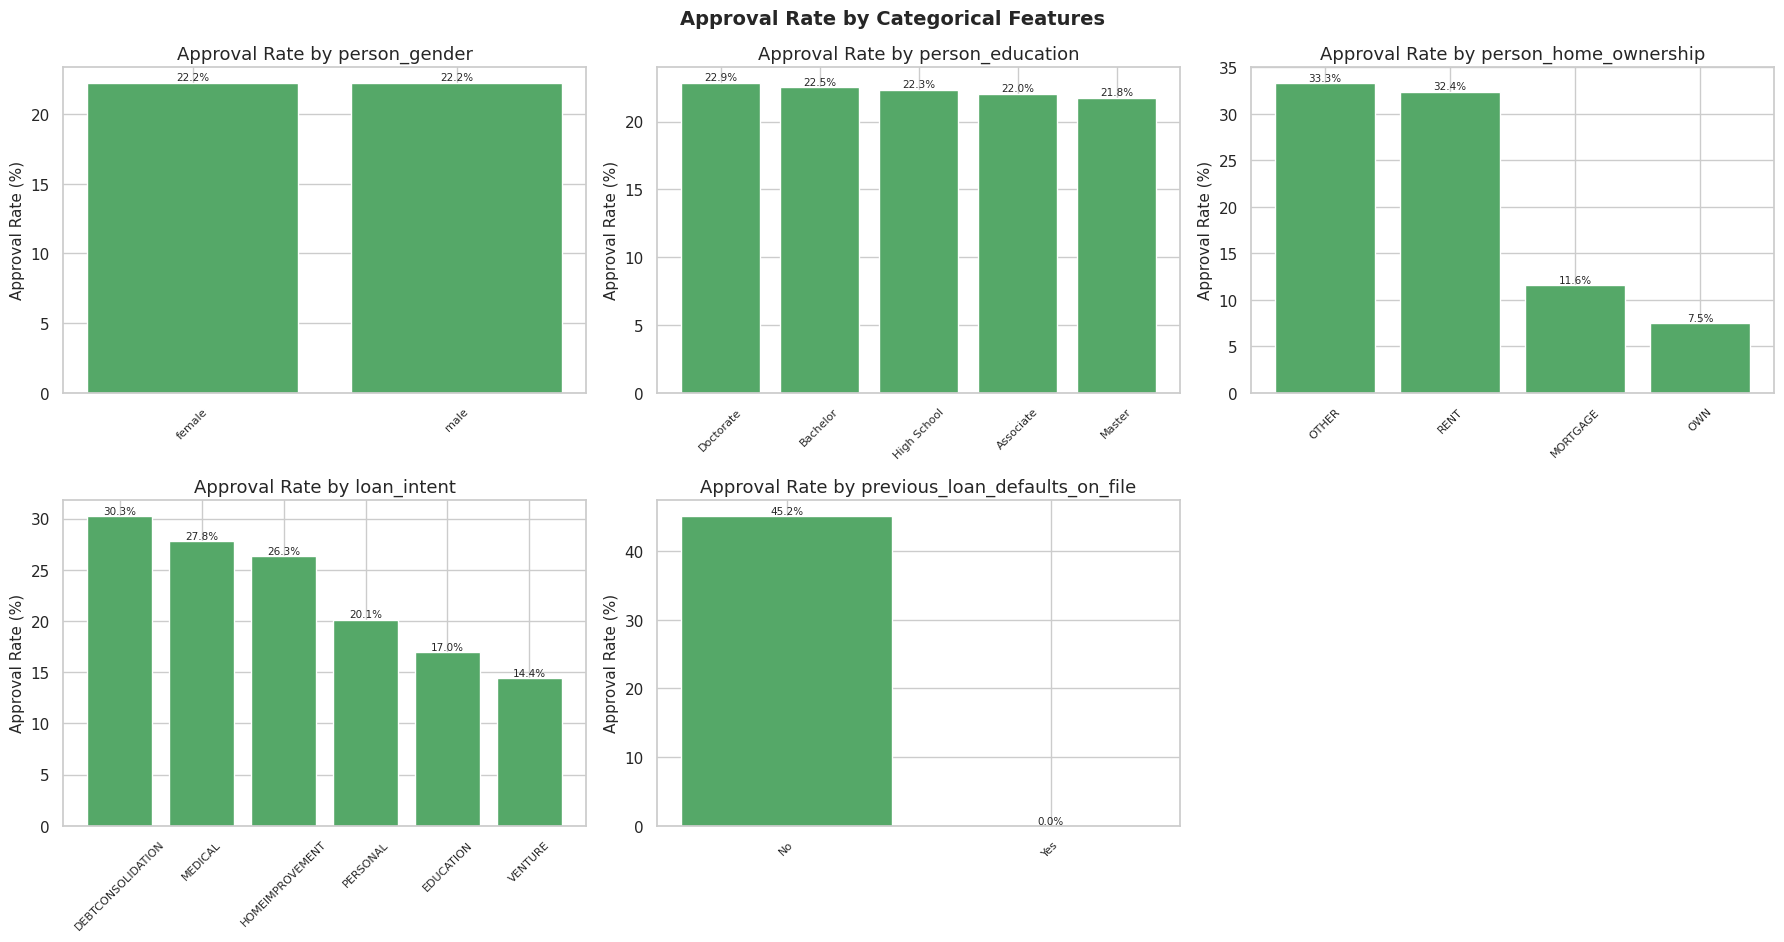

In [ ]:
cat_feats_orig = cat_cols[:9]

if cat_feats_orig:
    cols = 3
    rows = int(np.ceil(len(cat_feats_orig) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(18, 4.8 * rows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(cat_feats_orig):
        approval_rate = df.groupby(col)['loan_status'].mean().sort_values(ascending=False)
        bars = axes[i].bar(approval_rate.index.astype(str), approval_rate.values * 100,
                           color='#55A868', edgecolor='white', linewidth=1)
        axes[i].set_title(f'Approval Rate by {col}')
        axes[i].set_ylabel('Approval Rate (%)')
        axes[i].tick_params(axis='x', rotation=45, labelsize=8)
        for bar in bars:
            h = bar.get_height()
            axes[i].text(bar.get_x() + bar.get_width()/2, h + 0.2,
                         f'{h:.1f}%', ha='center', fontsize=7.5)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Approval Rate by Categorical Features', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('04_categorical_approval_rates.png', bbox_inches='tight')
    plt.show()
else:
    print('No original categorical features available for this plot.')


### 4.4 Correlation Heatmap


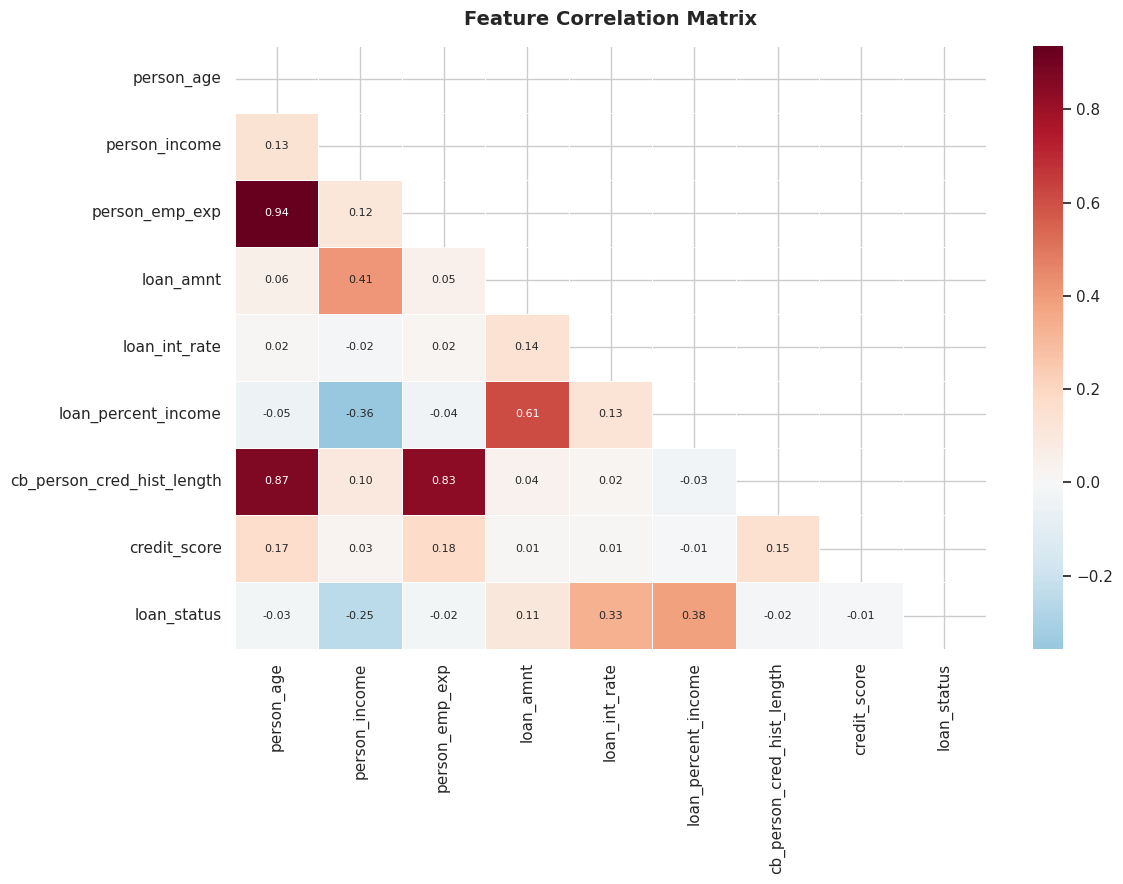

In [ ]:
heatmap_cols = [c for c in continuous_feats if c in df.columns][:12] + ['loan_status']
corr = df[heatmap_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('05_correlation_heatmap.png', bbox_inches='tight')
plt.show()


### 4.5 Pairplot - Key Features


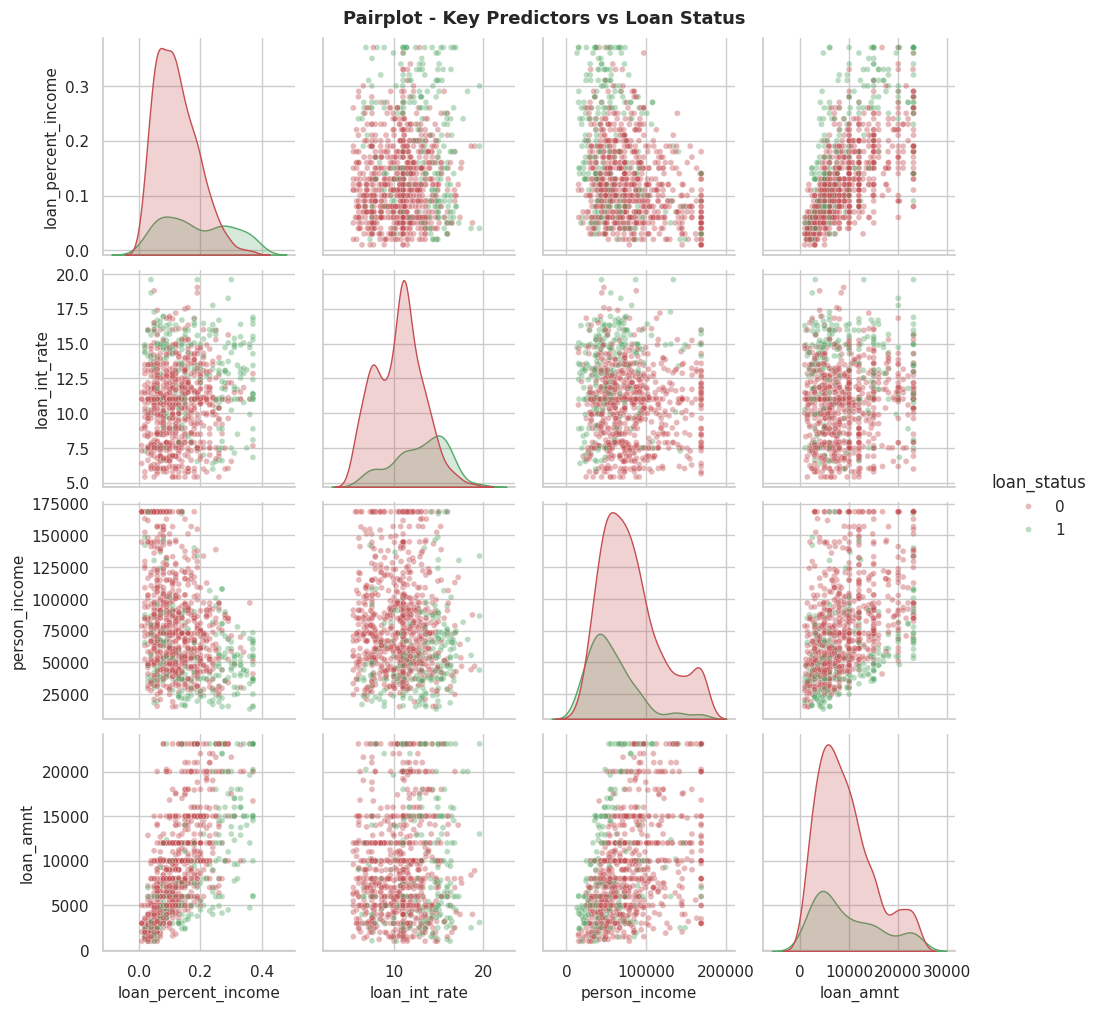

In [ ]:
# Select key numeric features most related to the target for a pairplot
corr_with_target = df[heatmap_cols].corr()['loan_status'].abs().sort_values(ascending=False)
key_features = corr_with_target.drop('loan_status').head(4).index.tolist() + ['loan_status']

sample_size = min(1000, len(df))
sample = df[key_features].sample(sample_size, random_state=RANDOM_STATE)

g = sns.pairplot(sample, hue='loan_status', palette=APPROVAL_COLORS,
                 plot_kws={'alpha': 0.4, 's': 18}, diag_kind='kde')
g.fig.suptitle('Pairplot - Key Predictors vs Loan Status', y=1.01, fontsize=13, fontweight='bold')
plt.savefig('06_pairplot.png', bbox_inches='tight')
plt.show()


## 5. Feature Selection <a id='5'></a>


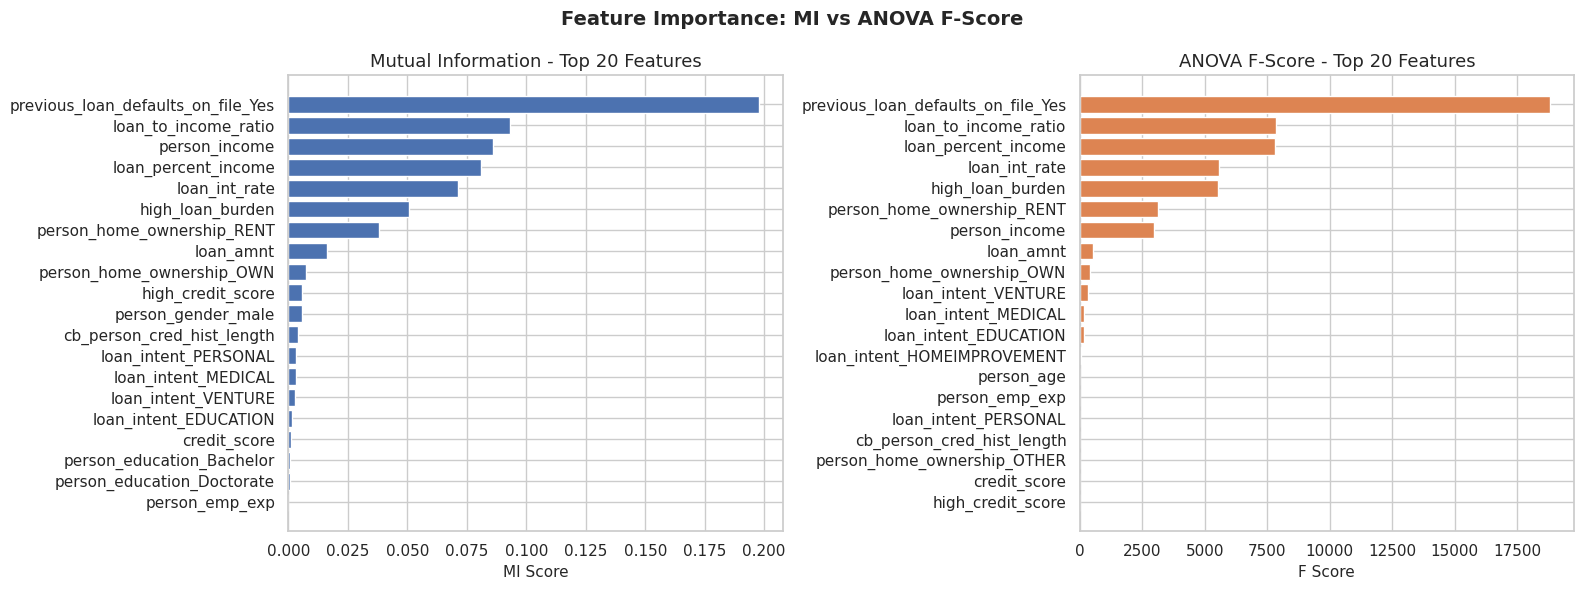

Selected 25 features for modelling.
['previous_loan_defaults_on_file_Yes', 'loan_to_income_ratio', 'person_income', 'loan_percent_income', 'loan_int_rate', 'high_loan_burden', 'person_home_ownership_RENT', 'loan_amnt', 'person_home_ownership_OWN', 'high_credit_score', 'person_gender_male', 'cb_person_cred_hist_length', 'loan_intent_PERSONAL', 'loan_intent_MEDICAL', 'loan_intent_VENTURE', 'loan_intent_EDUCATION', 'credit_score', 'person_education_Bachelor', 'person_education_Doctorate', 'person_emp_exp', 'person_age', 'person_home_ownership_OTHER', 'person_education_Master', 'person_education_High_School', 'loan_intent_HOMEIMPROVEMENT']


In [ ]:
X = df_encoded.drop(columns=['loan_status'])
y = df_encoded['loan_status']

mi = mutual_info_classif(X, y, random_state=RANDOM_STATE)
mi_series = pd.Series(mi, index=X.columns).sort_values(ascending=False)

selector = SelectKBest(f_classif, k='all')
selector.fit(X, y)
fscores = pd.Series(selector.scores_, index=X.columns).replace([np.inf, -np.inf], np.nan).fillna(0).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_mi = mi_series.head(20)
axes[0].barh(top_mi.index[::-1], top_mi.values[::-1], color='#4C72B0')
axes[0].set_title('Mutual Information - Top 20 Features')
axes[0].set_xlabel('MI Score')

top_f = fscores.head(20)
axes[1].barh(top_f.index[::-1], top_f.values[::-1], color='#DD8452')
axes[1].set_title('ANOVA F-Score - Top 20 Features')
axes[1].set_xlabel('F Score')

plt.suptitle('Feature Importance: MI vs ANOVA F-Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('07_feature_selection.png', bbox_inches='tight')
plt.show()

top_features = mi_series.head(min(25, X.shape[1])).index.tolist()
print(f"Selected {len(top_features)} features for modelling.")
print(top_features)


## 6. Model Building <a id='6'></a>


### 6.0 Train/Test Split & Shared Setup


In [ ]:
X_sel = X[top_features]

X_train, X_test, y_train, y_test = train_test_split(
    X_sel, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

# Scaled versions for distance/linear models
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Class weights help if approved/rejected classes are imbalanced
cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(zip(np.unique(y_train), cw))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

trained_models = {}
cv_results = {}

print(f"Training samples : {X_train.shape[0]:,}")
print(f"Test samples     : {X_test.shape[0]:,}")
print(f"Approval rate - train: {y_train.mean():.3f} | test: {y_test.mean():.3f}")
print(f"Class weights    : {class_weight_dict}")


Training samples : 36,000
Test samples     : 9,000
Approval rate - train: 0.222 | test: 0.222
Class weights    : {np.int64(0): np.float64(0.6428571428571429), np.int64(1): np.float64(2.25)}


### 6.1 Logistic Regression


In [ ]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)
lr_roc = cross_val_score(lr, X_train_sc, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
lr_f1  = cross_val_score(lr, X_train_sc, y_train, cv=cv, scoring='f1', n_jobs=-1)
lr_rec = cross_val_score(lr, X_train_sc, y_train, cv=cv, scoring='recall', n_jobs=-1)
lr.fit(X_train_sc, y_train)
trained_models['Logistic Regression'] = lr
cv_results['Logistic Regression'] = {'roc_auc': lr_roc, 'f1': lr_f1, 'recall': lr_rec}
print('Logistic Regression - 5-Fold Cross-Validation Results')
print(f"ROC-AUC : {lr_roc.mean():.4f} +/- {lr_roc.std():.4f}")
print(f"F1      : {lr_f1.mean():.4f} +/- {lr_f1.std():.4f}")
print(f"Recall  : {lr_rec.mean():.4f} +/- {lr_rec.std():.4f}")


Logistic Regression - 5-Fold Cross-Validation Results
ROC-AUC : 0.9540 +/- 0.0017
F1      : 0.7438 +/- 0.0036
Recall  : 0.9218 +/- 0.0090


### 6.2 Decision Tree


In [ ]:
dt = DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=RANDOM_STATE)
dt_roc = cross_val_score(dt, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
dt_f1  = cross_val_score(dt, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
dt_rec = cross_val_score(dt, X_train, y_train, cv=cv, scoring='recall', n_jobs=-1)
dt.fit(X_train, y_train)
trained_models['Decision Tree'] = dt
cv_results['Decision Tree'] = {'roc_auc': dt_roc, 'f1': dt_f1, 'recall': dt_rec}
print('Decision Tree - 5-Fold Cross-Validation Results')
print(f"ROC-AUC : {dt_roc.mean():.4f} +/- {dt_roc.std():.4f}")
print(f"F1      : {dt_f1.mean():.4f} +/- {dt_f1.std():.4f}")
print(f"Recall  : {dt_rec.mean():.4f} +/- {dt_rec.std():.4f}")


Decision Tree - 5-Fold Cross-Validation Results
ROC-AUC : 0.9601 +/- 0.0026
F1      : 0.7520 +/- 0.0147
Recall  : 0.8910 +/- 0.0357


### 6.3 Random Forest


In [ ]:
rf = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
rf_roc = cross_val_score(rf, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
rf_f1  = cross_val_score(rf, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
rf_rec = cross_val_score(rf, X_train, y_train, cv=cv, scoring='recall', n_jobs=-1)
rf.fit(X_train, y_train)
trained_models['Random Forest'] = rf
cv_results['Random Forest'] = {'roc_auc': rf_roc, 'f1': rf_f1, 'recall': rf_rec}
print('Random Forest - 5-Fold Cross-Validation Results')
print(f"ROC-AUC : {rf_roc.mean():.4f} +/- {rf_roc.std():.4f}")
print(f"F1      : {rf_f1.mean():.4f} +/- {rf_f1.std():.4f}")
print(f"Recall  : {rf_rec.mean():.4f} +/- {rf_rec.std():.4f}")


Random Forest - 5-Fold Cross-Validation Results
ROC-AUC : 0.9713 +/- 0.0019
F1      : 0.7979 +/- 0.0052
Recall  : 0.8901 +/- 0.0131


### 6.4 K-Nearest Neighbours (KNN)


In [ ]:
knn = KNeighborsClassifier(n_neighbors=11, metric='euclidean', n_jobs=-1)
knn_roc = cross_val_score(knn, X_train_sc, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
knn_f1  = cross_val_score(knn, X_train_sc, y_train, cv=cv, scoring='f1', n_jobs=-1)
knn_rec = cross_val_score(knn, X_train_sc, y_train, cv=cv, scoring='recall', n_jobs=-1)
knn.fit(X_train_sc, y_train)
trained_models['KNN'] = knn
cv_results['KNN'] = {'roc_auc': knn_roc, 'f1': knn_f1, 'recall': knn_rec}
print('KNN - 5-Fold Cross-Validation Results')
print(f"ROC-AUC : {knn_roc.mean():.4f} +/- {knn_roc.std():.4f}")
print(f"F1      : {knn_f1.mean():.4f} +/- {knn_f1.std():.4f}")
print(f"Recall  : {knn_rec.mean():.4f} +/- {knn_rec.std():.4f}")


KNN - 5-Fold Cross-Validation Results
ROC-AUC : 0.9379 +/- 0.0017
F1      : 0.7310 +/- 0.0041
Recall  : 0.6699 +/- 0.0058


### 6.5 Gradient Boosting


In [ ]:
gb = GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=RANDOM_STATE)
gb_roc = cross_val_score(gb, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
gb_f1  = cross_val_score(gb, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
gb_rec = cross_val_score(gb, X_train, y_train, cv=cv, scoring='recall', n_jobs=-1)
gb.fit(X_train, y_train)
trained_models['Gradient Boosting'] = gb
cv_results['Gradient Boosting'] = {'roc_auc': gb_roc, 'f1': gb_f1, 'recall': gb_rec}
print('Gradient Boosting - 5-Fold Cross-Validation Results')
print(f"ROC-AUC : {gb_roc.mean():.4f} +/- {gb_roc.std():.4f}")
print(f"F1      : {gb_f1.mean():.4f} +/- {gb_f1.std():.4f}")
print(f"Recall  : {gb_rec.mean():.4f} +/- {gb_rec.std():.4f}")


Gradient Boosting - 5-Fold Cross-Validation Results
ROC-AUC : 0.9765 +/- 0.0021
F1      : 0.8333 +/- 0.0086
Recall  : 0.7808 +/- 0.0116


### 6.6 Gaussian Naive Bayes

Gaussian Naive Bayes is a fast probabilistic model. It is useful as a comparison model because it assumes the numerical features follow a normal distribution and estimates approval probability directly.

In [ ]:
gnb = GaussianNB()
gnb_roc = cross_val_score(gnb, X_train_sc, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
gnb_f1  = cross_val_score(gnb, X_train_sc, y_train, cv=cv, scoring='f1', n_jobs=-1)
gnb_rec = cross_val_score(gnb, X_train_sc, y_train, cv=cv, scoring='recall', n_jobs=-1)
gnb.fit(X_train_sc, y_train)
trained_models['Gaussian Naive Bayes'] = gnb
cv_results['Gaussian Naive Bayes'] = {'roc_auc': gnb_roc, 'f1': gnb_f1, 'recall': gnb_rec}
print('Gaussian Naive Bayes - 5-Fold Cross-Validation Results')
print(f"ROC-AUC : {gnb_roc.mean():.4f} +/- {gnb_roc.std():.4f}")
print(f"F1      : {gnb_f1.mean():.4f} +/- {gnb_f1.std():.4f}")
print(f"Recall  : {gnb_rec.mean():.4f} +/- {gnb_rec.std():.4f}")

Gaussian Naive Bayes - 5-Fold Cross-Validation Results
ROC-AUC : 0.9361 +/- 0.0012
F1      : 0.6313 +/- 0.0046
Recall  : 0.9836 +/- 0.0040


### 6.7 AdaBoost Classifier

AdaBoost combines many weak learners into a stronger classifier. It is appropriate for loan approval prediction because it can focus more on difficult-to-classify applications.

In [ ]:
ada = AdaBoostClassifier(n_estimators=150, learning_rate=0.08, random_state=RANDOM_STATE)
ada_roc = cross_val_score(ada, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
ada_f1  = cross_val_score(ada, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
ada_rec = cross_val_score(ada, X_train, y_train, cv=cv, scoring='recall', n_jobs=-1)
ada.fit(X_train, y_train)
trained_models['AdaBoost'] = ada
cv_results['AdaBoost'] = {'roc_auc': ada_roc, 'f1': ada_f1, 'recall': ada_rec}
print('AdaBoost - 5-Fold Cross-Validation Results')
print(f"ROC-AUC : {ada_roc.mean():.4f} +/- {ada_roc.std():.4f}")
print(f"F1      : {ada_f1.mean():.4f} +/- {ada_f1.std():.4f}")
print(f"Recall  : {ada_rec.mean():.4f} +/- {ada_rec.std():.4f}")

AdaBoost - 5-Fold Cross-Validation Results
ROC-AUC : 0.9456 +/- 0.0024
F1      : 0.7292 +/- 0.0095
Recall  : 0.6510 +/- 0.0230


### 6.8 Extra Trees Classifier

Extra Trees is an ensemble tree model similar to Random Forest, but it adds more randomness while splitting features. This helps compare whether a more randomized ensemble improves classification performance.

In [ ]:
et = ExtraTreesClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
et_roc = cross_val_score(et, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
et_f1  = cross_val_score(et, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
et_rec = cross_val_score(et, X_train, y_train, cv=cv, scoring='recall', n_jobs=-1)
et.fit(X_train, y_train)
trained_models['Extra Trees'] = et
cv_results['Extra Trees'] = {'roc_auc': et_roc, 'f1': et_f1, 'recall': et_rec}
print('Extra Trees - 5-Fold Cross-Validation Results')
print(f"ROC-AUC : {et_roc.mean():.4f} +/- {et_roc.std():.4f}")
print(f"F1      : {et_f1.mean():.4f} +/- {et_f1.std():.4f}")
print(f"Recall  : {et_rec.mean():.4f} +/- {et_rec.std():.4f}")

Extra Trees - 5-Fold Cross-Validation Results
ROC-AUC : 0.9620 +/- 0.0015
F1      : 0.7381 +/- 0.0027
Recall  : 0.9460 +/- 0.0068


### 6.6 Cross-Validation Summary


In [ ]:
cv_summary = []
for name, scores in cv_results.items():
    cv_summary.append({
        'Model': name,
        'ROC-AUC Mean': scores['roc_auc'].mean(),
        'F1 Mean': scores['f1'].mean(),
        'Recall Mean': scores['recall'].mean(),
        'ROC-AUC Std': scores['roc_auc'].std()
    })

cv_summary_df = pd.DataFrame(cv_summary).sort_values('ROC-AUC Mean', ascending=False).reset_index(drop=True)
cv_summary_df.round(4)


,Model,ROC-AUC Mean,F1 Mean,Recall Mean,ROC-AUC Std
0,Gradient Boosting,0.9765,0.8333,0.7808,0.0021
1,Random Forest,0.9713,0.7979,0.8901,0.0019
2,Extra Trees,0.9620,0.7381,0.9460,0.0015
3,Decision Tree,0.9601,0.7520,0.8910,0.0026
4,Logistic Regression,0.9540,0.7438,0.9218,0.0017
5,AdaBoost,0.9456,0.7292,0.6510,0.0024
6,KNN,0.9379,0.7310,0.6699,0.0017
7,Gaussian Naive Bayes,0.9361,0.6313,0.9836,0.0012


## 7. Model Optimization (Hyperparameter Tuning) <a id='7'></a>


### 7.1 Random Forest - GridSearchCV


In [ ]:
rf_grid = {
    'n_estimators': [150, 250],
    'max_depth': [8, 12, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_search = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    rf_grid, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=1
)
rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_
trained_models['Random Forest (Tuned)'] = best_rf

print('Best Random Forest parameters:', rf_search.best_params_)
print(f"Best CV ROC-AUC: {rf_search.best_score_:.4f}")


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Random Forest parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 250}
Best CV ROC-AUC: 0.9740


### 7.2 KNN - GridSearchCV


In [ ]:
knn_grid = {
    'n_neighbors': [5, 7, 11, 15, 21],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn_search = GridSearchCV(
    KNeighborsClassifier(n_jobs=-1),
    knn_grid, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=1
)
knn_search.fit(X_train_sc, y_train)
best_knn = knn_search.best_estimator_
trained_models['KNN (Tuned)'] = best_knn

print('Best KNN parameters:', knn_search.best_params_)
print(f"Best CV ROC-AUC: {knn_search.best_score_:.4f}")


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best KNN parameters: {'metric': 'manhattan', 'n_neighbors': 21, 'weights': 'distance'}
Best CV ROC-AUC: 0.9511


### 7.3 Gradient Boosting - GridSearchCV


In [ ]:
gb_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.10],
    'max_depth': [3, 4],
    'subsample': [0.8, 1.0]
}

gb_search = GridSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    gb_grid, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=1
)
gb_search.fit(X_train, y_train)
best_gb = gb_search.best_estimator_
trained_models['Gradient Boosting (Tuned)'] = best_gb

print('Best Gradient Boosting parameters:', gb_search.best_params_)
print(f"Best CV ROC-AUC: {gb_search.best_score_:.4f}")


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Gradient Boosting parameters: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
Best CV ROC-AUC: 0.9769


## 8. Model Evaluation <a id='8'></a>


### 8.0 Generate Predictions for All Models


In [ ]:
preds = {}
scaled_model_names = ['Logistic Regression', 'KNN', 'KNN (Tuned)', 'Gaussian Naive Bayes']

for name, model in trained_models.items():
    X_te = X_test_sc if name in scaled_model_names else X_test.values
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    preds[name] = {'y_pred': y_pred, 'y_proba': y_proba}

print('Predictions generated for all models.')
print(f"Models evaluated: {list(preds.keys())}")


Predictions generated for all models.
Models evaluated: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'KNN', 'Gradient Boosting', 'Gaussian Naive Bayes', 'AdaBoost', 'Extra Trees', 'Random Forest (Tuned)', 'KNN (Tuned)', 'Gradient Boosting (Tuned)']


### 8.1 Accuracy


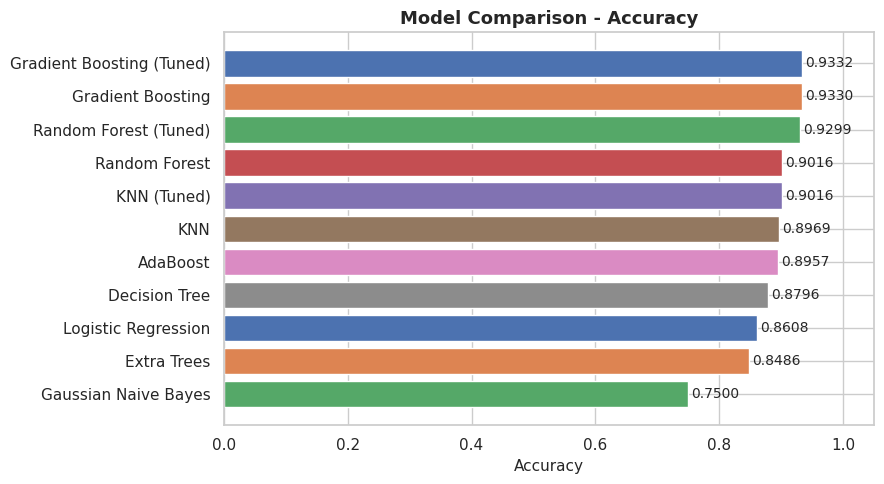

,Model,Accuracy
0,Gradient Boosting (Tuned),0.9332
1,Gradient Boosting,0.9330
2,Random Forest (Tuned),0.9299
3,Random Forest,0.9016
4,KNN (Tuned),0.9016
5,KNN,0.8969
6,AdaBoost,0.8957
7,Decision Tree,0.8796
8,Logistic Regression,0.8608
9,Extra Trees,0.8486


In [ ]:
rows = []
for name, p in preds.items():
    score = accuracy_score(y_test, p['y_pred'])
    rows.append({'Model': name, 'Accuracy': round(score, 4)})

metric_df = pd.DataFrame(rows).sort_values('Accuracy', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 5))
plot_colors = (MODEL_COLORS * int(np.ceil(len(metric_df) / len(MODEL_COLORS))))[:len(metric_df)]
bars = ax.barh(metric_df['Model'][::-1], metric_df['Accuracy'][::-1], color=plot_colors[::-1], edgecolor='white')
ax.set_xlim(0, 1.05)
ax.set_xlabel('Accuracy')
ax.set_title('Model Comparison - Accuracy', fontsize=13, fontweight='bold')
for bar, val in zip(bars, metric_df['Accuracy'][::-1]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('08_accuracy.png', bbox_inches='tight')
plt.show()

metric_df


### 8.2 Precision


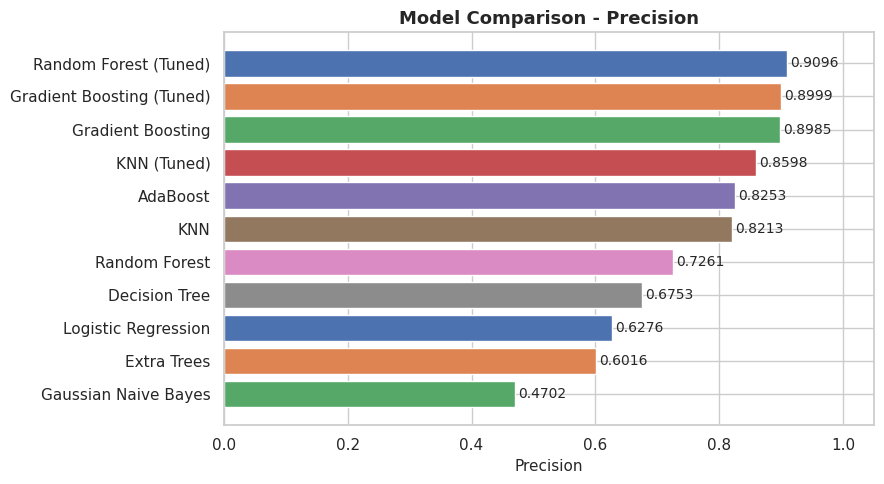

,Model,Precision
0,Random Forest (Tuned),0.9096
1,Gradient Boosting (Tuned),0.8999
2,Gradient Boosting,0.8985
3,KNN (Tuned),0.8598
4,AdaBoost,0.8253
5,KNN,0.8213
6,Random Forest,0.7261
7,Decision Tree,0.6753
8,Logistic Regression,0.6276
9,Extra Trees,0.6016


In [ ]:
rows = []
for name, p in preds.items():
    score = precision_score(y_test, p['y_pred'], zero_division=0)
    rows.append({'Model': name, 'Precision': round(score, 4)})

metric_df = pd.DataFrame(rows).sort_values('Precision', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 5))
plot_colors = (MODEL_COLORS * int(np.ceil(len(metric_df) / len(MODEL_COLORS))))[:len(metric_df)]
bars = ax.barh(metric_df['Model'][::-1], metric_df['Precision'][::-1], color=plot_colors[::-1], edgecolor='white')
ax.set_xlim(0, 1.05)
ax.set_xlabel('Precision')
ax.set_title('Model Comparison - Precision', fontsize=13, fontweight='bold')
for bar, val in zip(bars, metric_df['Precision'][::-1]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('08_precision.png', bbox_inches='tight')
plt.show()

metric_df


### 8.3 Recall


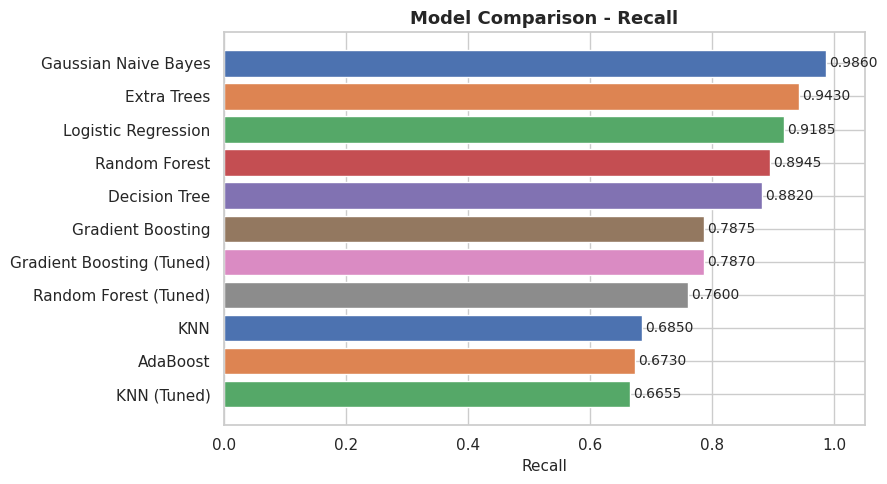

,Model,Recall
0,Gaussian Naive Bayes,0.9860
1,Extra Trees,0.9430
2,Logistic Regression,0.9185
3,Random Forest,0.8945
4,Decision Tree,0.8820
5,Gradient Boosting,0.7875
6,Gradient Boosting (Tuned),0.7870
7,Random Forest (Tuned),0.7600
8,KNN,0.6850
9,AdaBoost,0.6730


In [ ]:
rows = []
for name, p in preds.items():
    score = recall_score(y_test, p['y_pred'], zero_division=0)
    rows.append({'Model': name, 'Recall': round(score, 4)})

metric_df = pd.DataFrame(rows).sort_values('Recall', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 5))
plot_colors = (MODEL_COLORS * int(np.ceil(len(metric_df) / len(MODEL_COLORS))))[:len(metric_df)]
bars = ax.barh(metric_df['Model'][::-1], metric_df['Recall'][::-1], color=plot_colors[::-1], edgecolor='white')
ax.set_xlim(0, 1.05)
ax.set_xlabel('Recall')
ax.set_title('Model Comparison - Recall', fontsize=13, fontweight='bold')
for bar, val in zip(bars, metric_df['Recall'][::-1]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('08_recall.png', bbox_inches='tight')
plt.show()

metric_df


### 8.4 F1-Score


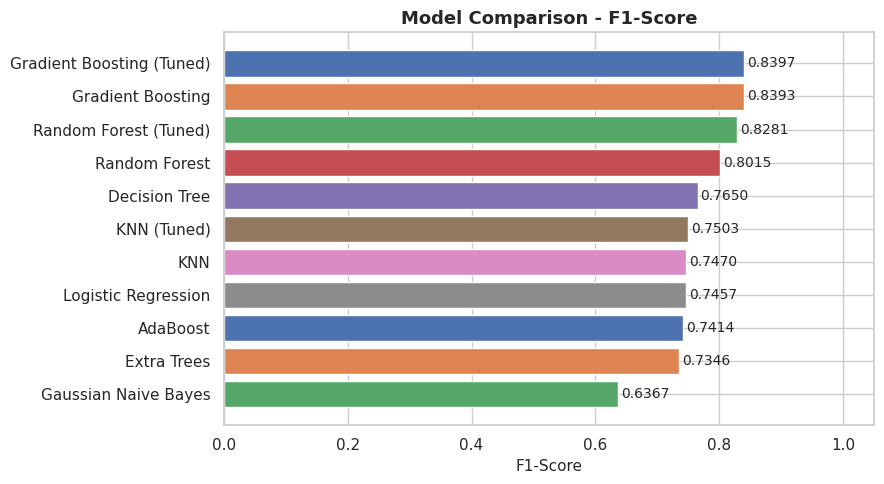

,Model,F1-Score
0,Gradient Boosting (Tuned),0.8397
1,Gradient Boosting,0.8393
2,Random Forest (Tuned),0.8281
3,Random Forest,0.8015
4,Decision Tree,0.7650
5,KNN (Tuned),0.7503
6,KNN,0.7470
7,Logistic Regression,0.7457
8,AdaBoost,0.7414
9,Extra Trees,0.7346


In [ ]:
rows = []
for name, p in preds.items():
    score = f1_score(y_test, p['y_pred'], zero_division=0)
    rows.append({'Model': name, 'F1-Score': round(score, 4)})

metric_df = pd.DataFrame(rows).sort_values('F1-Score', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 5))
plot_colors = (MODEL_COLORS * int(np.ceil(len(metric_df) / len(MODEL_COLORS))))[:len(metric_df)]
bars = ax.barh(metric_df['Model'][::-1], metric_df['F1-Score'][::-1], color=plot_colors[::-1], edgecolor='white')
ax.set_xlim(0, 1.05)
ax.set_xlabel('F1-Score')
ax.set_title('Model Comparison - F1-Score', fontsize=13, fontweight='bold')
for bar, val in zip(bars, metric_df['F1-Score'][::-1]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('08_f1_score.png', bbox_inches='tight')
plt.show()

metric_df


### 8.5 ROC-AUC


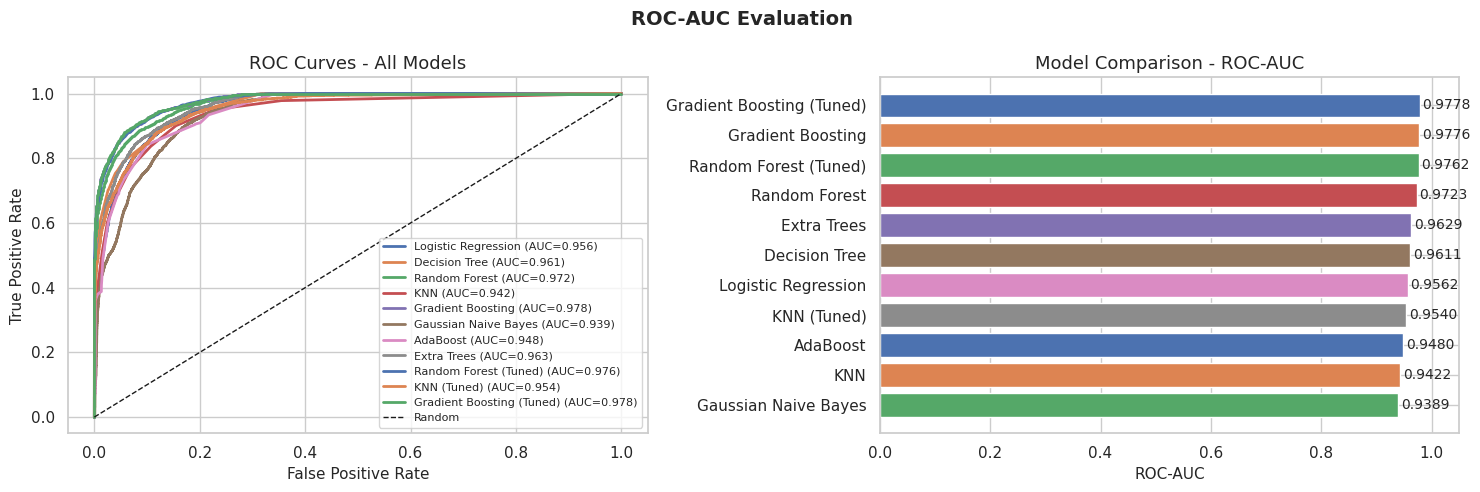

,Model,ROC-AUC
0,Gradient Boosting (Tuned),0.9778
1,Gradient Boosting,0.9776
2,Random Forest (Tuned),0.9762
3,Random Forest,0.9723
4,Extra Trees,0.9629
5,Decision Tree,0.9611
6,Logistic Regression,0.9562
7,KNN (Tuned),0.9540
8,AdaBoost,0.9480
9,KNN,0.9422


In [ ]:
auc_rows = []
for name, p in preds.items():
    auc = roc_auc_score(y_test, p['y_proba'])
    auc_rows.append({'Model': name, 'ROC-AUC': round(auc, 4)})

auc_df = pd.DataFrame(auc_rows).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

plot_colors = (MODEL_COLORS * int(np.ceil(len(preds) / len(MODEL_COLORS))))[:len(preds)]
for (name, p), color in zip(preds.items(), plot_colors):
    fpr, tpr, _ = roc_curve(y_test, p['y_proba'])
    auc = roc_auc_score(y_test, p['y_proba'])
    axes[0].plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC={auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves - All Models')
axes[0].legend(fontsize=8)

bars = axes[1].barh(auc_df['Model'][::-1], auc_df['ROC-AUC'][::-1], color=plot_colors[:len(auc_df)][::-1], edgecolor='white')
axes[1].set_xlim(0, 1.05)
axes[1].set_xlabel('ROC-AUC')
axes[1].set_title('Model Comparison - ROC-AUC')
for bar, val in zip(bars, auc_df['ROC-AUC'][::-1]):
    axes[1].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=10)

plt.suptitle('ROC-AUC Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('08_roc_auc.png', bbox_inches='tight')
plt.show()

auc_df


### 8.6 Confusion Matrices


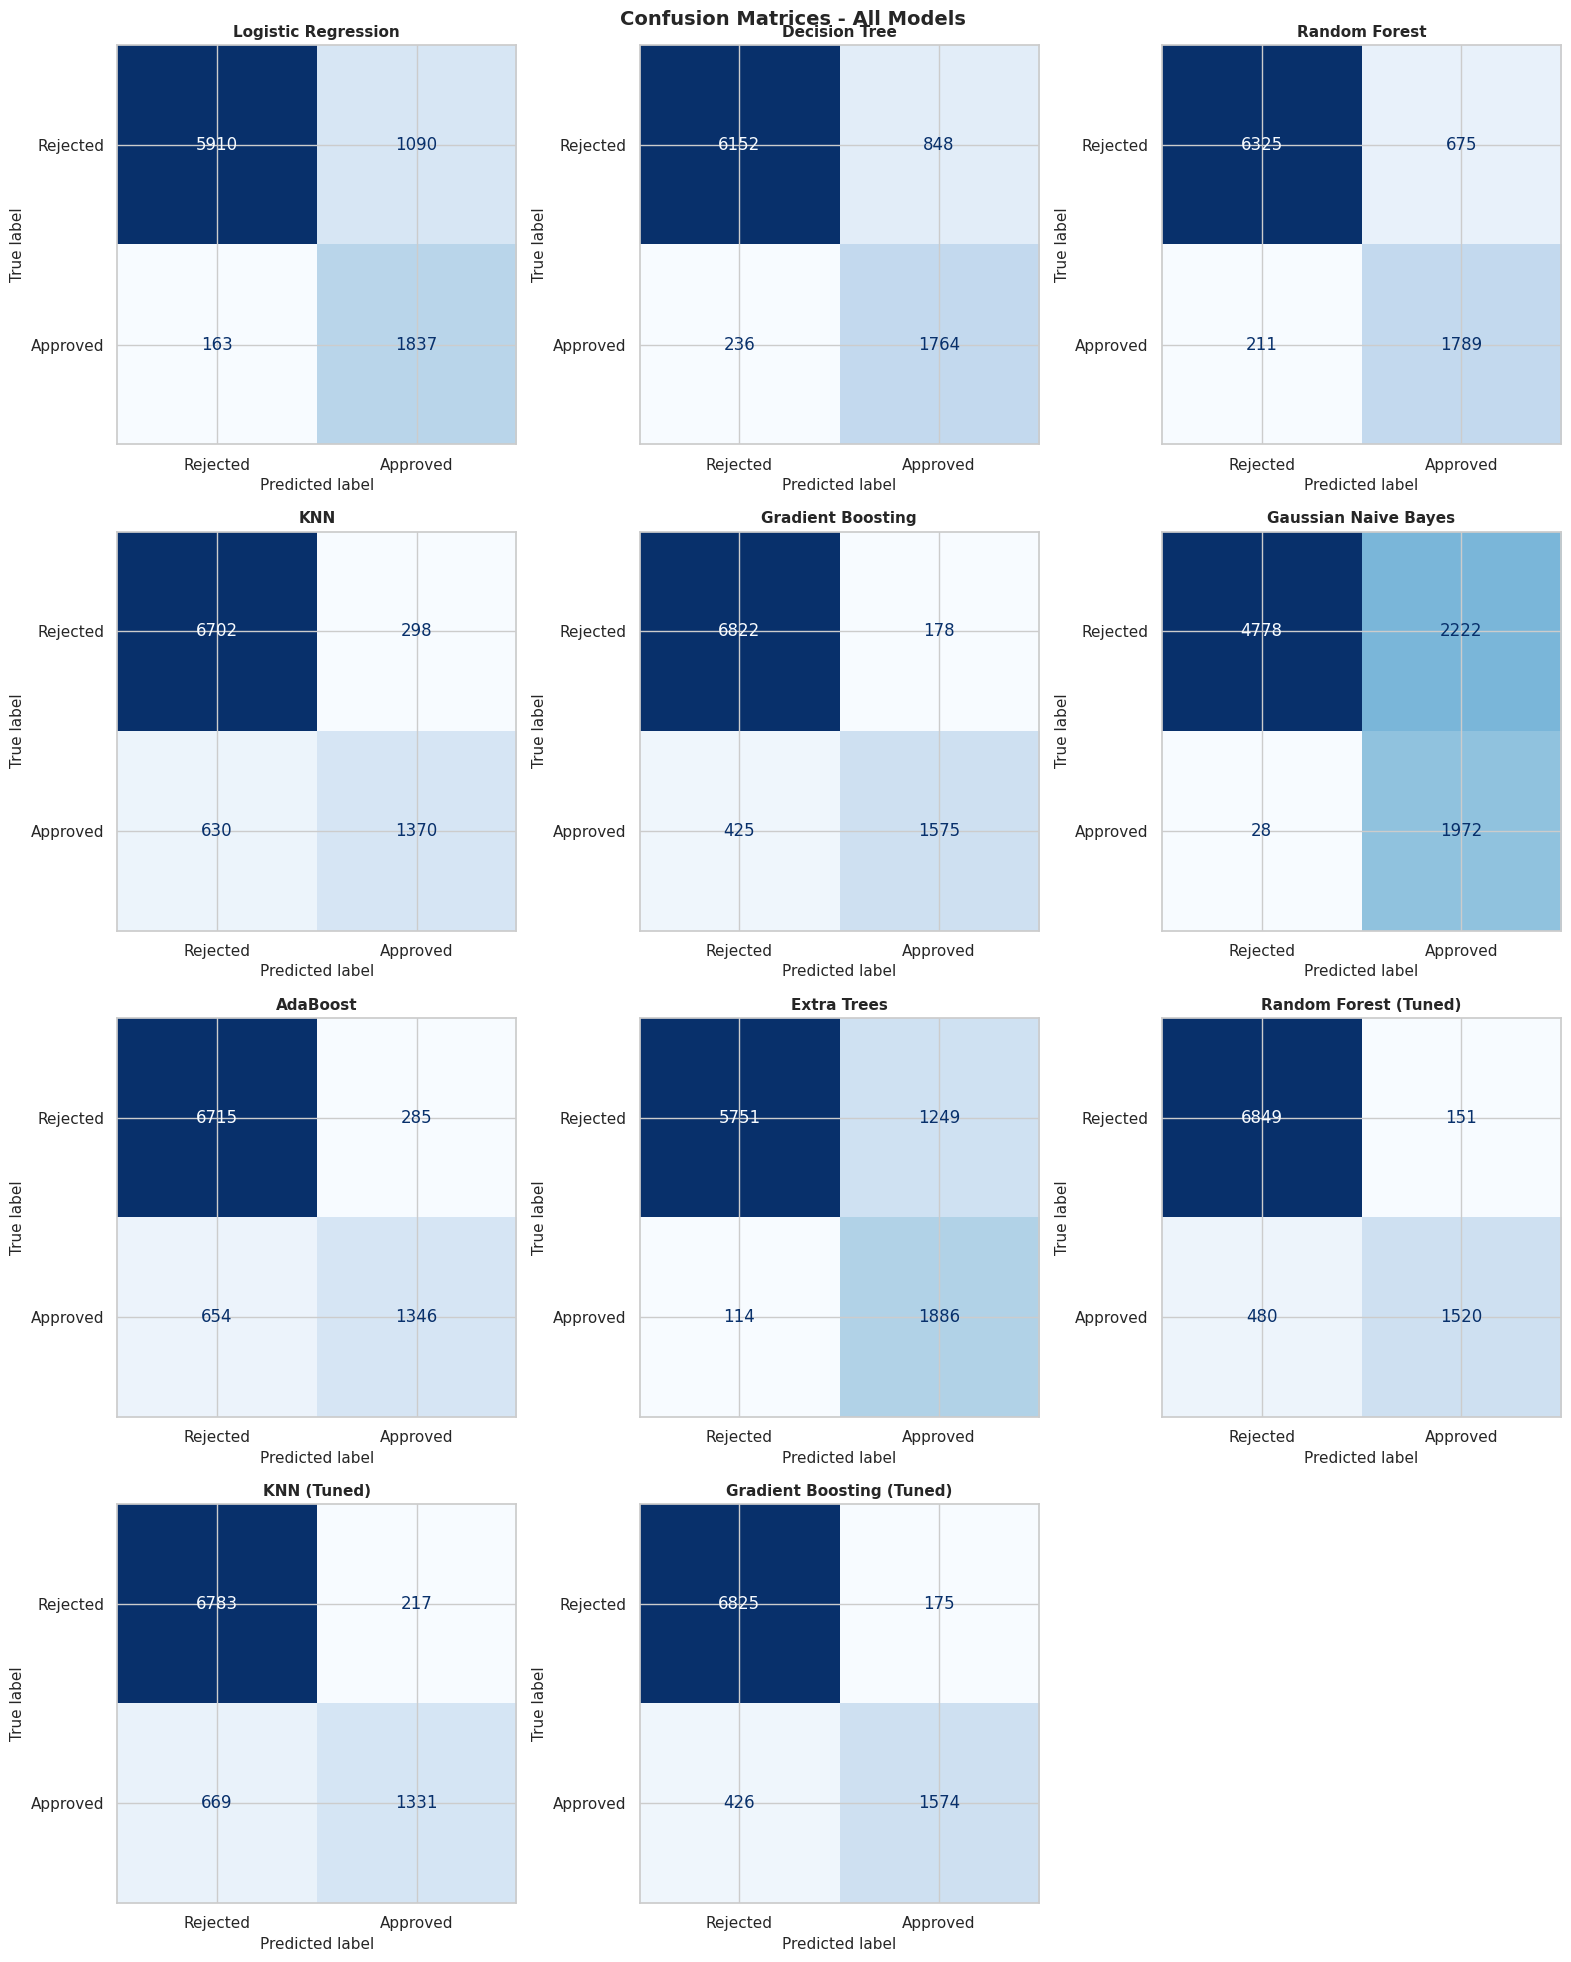

In [ ]:
cols = 3
rows = int(np.ceil(len(preds) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))
axes = np.array(axes).reshape(-1)

for i, (name, p) in enumerate(preds.items()):
    cm = confusion_matrix(y_test, p['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Rejected', 'Approved'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(name, fontsize=11, fontweight='bold')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion Matrices - All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('08_confusion_matrices.png', bbox_inches='tight')
plt.show()


### 8.7 Full Classification Reports


In [ ]:
for name, p in preds.items():
    print('=' * 60)
    print(f'  {name}')
    print('=' * 60)
    print(classification_report(y_test, p['y_pred'], target_names=['Rejected (0)', 'Approved (1)']))
    print()


  Logistic Regression
              precision    recall  f1-score   support

Rejected (0)       0.97      0.84      0.90      7000
Approved (1)       0.63      0.92      0.75      2000

    accuracy                           0.86      9000
   macro avg       0.80      0.88      0.82      9000
weighted avg       0.90      0.86      0.87      9000


  Decision Tree
              precision    recall  f1-score   support

Rejected (0)       0.96      0.88      0.92      7000
Approved (1)       0.68      0.88      0.76      2000

    accuracy                           0.88      9000
   macro avg       0.82      0.88      0.84      9000
weighted avg       0.90      0.88      0.88      9000


  Random Forest
              precision    recall  f1-score   support

Rejected (0)       0.97      0.90      0.93      7000
Approved (1)       0.73      0.89      0.80      2000

    accuracy                           0.90      9000
   macro avg       0.85      0.90      0.87      9000
weighted avg      

### 8.8 Overall Performance Summary


In [ ]:
summary_rows = []
for name, p in preds.items():
    summary_rows.append({
        'Model'     : name,
        'Accuracy'  : round(accuracy_score(y_test, p['y_pred']), 4),
        'Precision' : round(precision_score(y_test, p['y_pred'], zero_division=0), 4),
        'Recall'    : round(recall_score(y_test, p['y_pred'], zero_division=0), 4),
        'F1-Score'  : round(f1_score(y_test, p['y_pred'], zero_division=0), 4),
        'ROC-AUC'   : round(roc_auc_score(y_test, p['y_proba']), 4),
    })

summary_df = pd.DataFrame(summary_rows).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
summary_df.style.background_gradient(cmap='YlGn', subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'])


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Gradient Boosting (Tuned),0.933200,0.899900,0.787000,0.839700,0.977800
1,Gradient Boosting,0.933000,0.898500,0.787500,0.839300,0.977600
2,Random Forest (Tuned),0.929900,0.909600,0.760000,0.828100,0.976200
3,Random Forest,0.901600,0.726100,0.894500,0.801500,0.972300
4,Extra Trees,0.848600,0.601600,0.943000,0.734600,0.962900
5,Decision Tree,0.879600,0.675300,0.882000,0.765000,0.961100
6,Logistic Regression,0.860800,0.627600,0.918500,0.745700,0.956200
7,KNN (Tuned),0.901600,0.859800,0.665500,0.750300,0.954000
8,AdaBoost,0.895700,0.825300,0.673000,0.741400,0.948000
9,KNN,0.896900,0.821300,0.685000,0.747000,0.942200


### 8.9 Feature Importances - Top Models


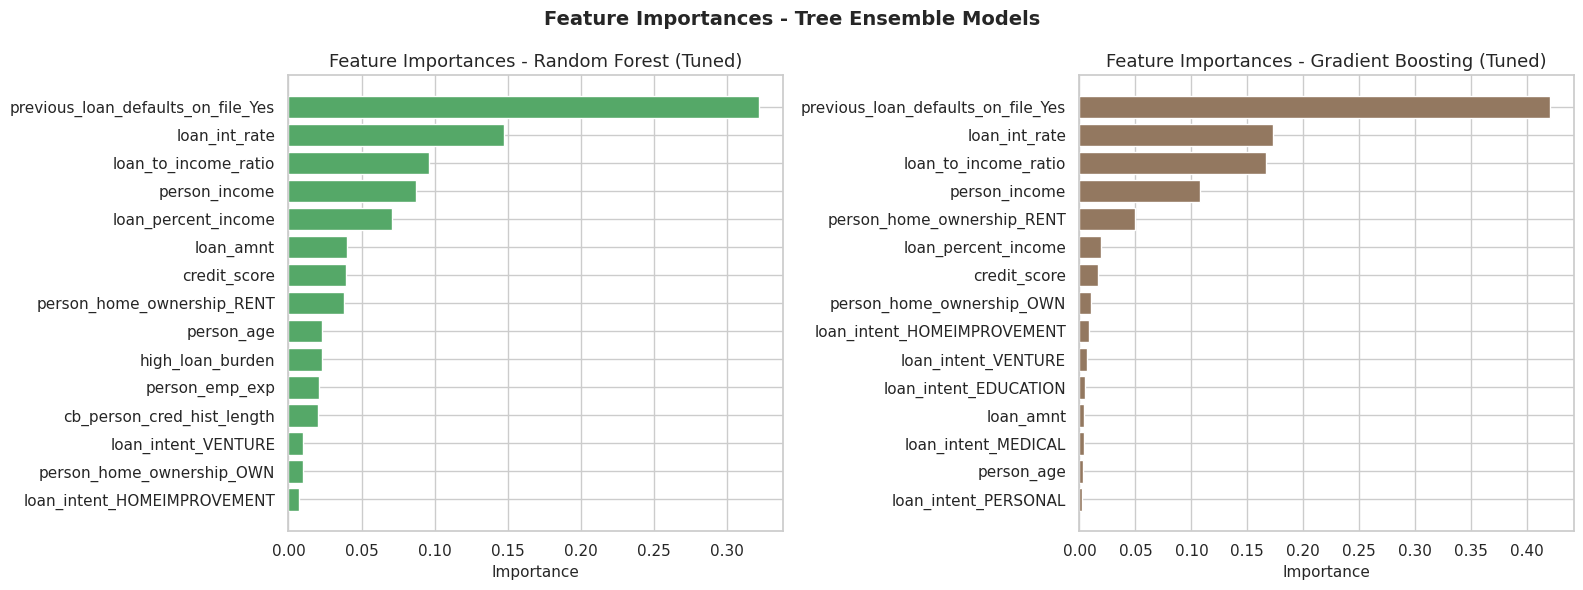

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

imp_rf = pd.Series(best_rf.feature_importances_, index=top_features).sort_values(ascending=False).head(15)
axes[0].barh(imp_rf.index[::-1], imp_rf.values[::-1], color='#55A868')
axes[0].set_title('Feature Importances - Random Forest (Tuned)')
axes[0].set_xlabel('Importance')

imp_gb = pd.Series(best_gb.feature_importances_, index=top_features).sort_values(ascending=False).head(15)
axes[1].barh(imp_gb.index[::-1], imp_gb.values[::-1], color='#937860')
axes[1].set_title('Feature Importances - Gradient Boosting (Tuned)')
axes[1].set_xlabel('Importance')

plt.suptitle('Feature Importances - Tree Ensemble Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('09_feature_importances.png', bbox_inches='tight')
plt.show()


## 9. Business Insights & Recommendations <a id='9'></a>

### 9.1 Key Predictors & Their Business Meaning

| Predictor Area | Expected Impact on Approval | Business Interpretation |
|---|---|---|
| Credit score / credit history | Higher score usually increases approval probability | Strong repayment history lowers credit risk and supports automated approval decisions. |
| Loan amount and loan-to-income ratio | Higher burden usually lowers approval probability | Applicants requesting loans that are too large relative to income may be riskier. |
| Income level | Higher income generally supports approval | Income improves repayment capacity and reduces default risk. |
| Employment length | Longer employment can support approval | Stable employment suggests stable cash flow. |
| Interest rate / loan grade | Riskier loans may have higher interest and lower approval probability | Pricing and approval decisions are connected to estimated borrower risk. |
| Loan purpose | Some purposes may be associated with different approval rates | Banks can adjust risk rules by loan use case. |

---

### 9.2 Actionable Recommendations

**1. Use the best model as a decision-support tool**  
Deploy the model with the strongest ROC-AUC and F1-score to support loan officers. The model should recommend approval probability, not replace final human judgment.

**2. Prioritize high-recall screening for risky rejections**  
For loan approval, false approvals may create default risk, while false rejections may lose good customers. The bank should choose a threshold based on its risk appetite.

**3. Explain decisions using key features**  
Feature importance results can help explain which factors influence approval decisions, such as credit score, income, loan amount, and loan-to-income ratio.

**4. Improve customer guidance**  
Rejected applicants can be given improvement suggestions, such as reducing requested loan amount, improving credit score, or applying after longer employment stability.

**5. Monitor fairness and bias**  
The business should regularly audit model outcomes to make sure approval decisions are not unfairly biased against protected or vulnerable groups.

---

### 9.3 Limitations and Future Improvements

- The Kaggle dataset may be synthetic or simplified compared with real bank data.
- External macroeconomic factors such as inflation, interest rates, and unemployment are not included.
- Model performance may change over time, so retraining and monitoring are necessary.
- Future work can test more models such as XGBoost, LightGBM, or CatBoost.
- Threshold optimization can be added to balance approval growth and default-risk control.
